# Week2_복습과제_김이화

**2주차 논문(Transformer) 관련 코드 실습**

- 교재: *(파이토치 트랜스포머를 활용한) 자연어 처리와 컴퓨터 비전 심층학습*
- 범위: 7장. 트랜스포머 (p.357~387)
- 내용: 교재의 예제 7.1 ~ 7.8을 그대로 따라가며, 위치 인코딩부터 트랜스포머 인코더/디코더 모델 구성, 데이터 전처리, 마스크 생성, 학습·평가, 번역 결과 확인까지 직접 실행해봅니다.

> **실습 환경 관련 안내**
> 교재는 `torchtext.datasets.Multi30k`로 Multi30k 데이터셋을 바로 내려받는 방식을 사용하지만, `torchtext`가 2024년부터 공식적으로 **deprecated**되면서 내부적으로 쓰는 `torchdata`의 데이터 다운로드 파이프라인이 현재 배포되는 torch/torchdata 조합과 호환되지 않아(`ImportError: cannot import name 'DILL_AVAILABLE'...`) 정상적으로 동작하지 않았습니다. 이는 이 교재 예제를 최신 환경에서 실습할 때 흔히 발생하는 이슈입니다.
> 따라서 이 노트북에서는 Multi30k 원본 데이터(공식 GitHub 저장소 `multi30k/dataset`의 `task1/raw` 영-독 병렬 말뭉치)를 직접 내려받아 동일한 형태의 `(src, tgt)` 이터레이터로 감싸서 사용했습니다. **토크나이저(spaCy), 어휘 사전 생성, 모델 구조, 마스크 생성, 학습 루프, 번역(추론) 코드는 모두 교재와 동일**합니다.
> 또한 CPU 2코어 환경이라 전체 29,000쌍 × 5에폭을 그대로 학습하면 시간이 매우 오래 걸려, 학습에는 학습 데이터 중 앞부분 5,000쌍만 사용하고 에폭 수를 3으로 줄였습니다(코드 구조는 교재와 동일, 데이터/에폭 규모만 축소). 검증에는 공식 validation set(1,014쌍) 중 300쌍을 사용했습니다.


## 예제 7.1 위치 인코딩 (Positional Encoding)

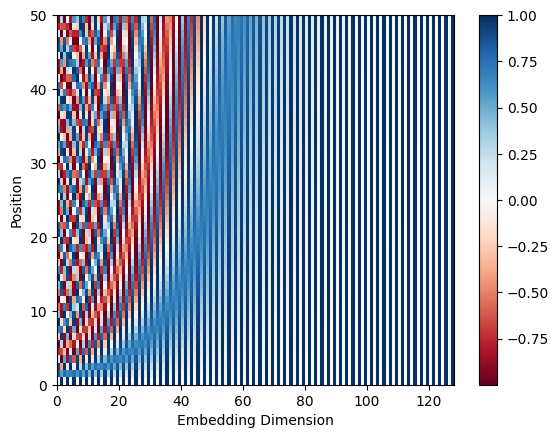

In [1]:
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)


encoding = PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0, 128))
plt.ylabel("Position")
plt.colorbar()
plt.show()


`PositionalEncoding` 클래스는 입력 임베딩 차원(`d_model`)과 최대 시퀀스 길이(`max_len`)를 입력받아, 입력 시퀀스의 위치마다 $\sin$과 $\cos$ 함수로 위치 인코딩을 계산합니다.

$$PE(pos, 2i) = \sin(pos / 10000^{2i/d_{model}})$$
$$PE(pos, 2i+1) = \cos(pos / 10000^{2i/d_{model}})$$

`pos`는 입력 시퀀스에서 해당 단어의 위치, `i`는 임베딩 벡터의 차원 인덱스를 의미합니다. 차원 인덱스가 짝수면 `sin` 함수를, 홀수면 `cos` 함수를 적용합니다. `pe` 텐서의 차원은 `[최대 시퀀스, 1, 128]`이며, 출력 결과에서 위치별 임베딩 차원이 주기적인 값으로 구성되는 것을 확인할 수 있습니다. `register_buffer`는 모델의 매개변수를 갱신하지 않도록(학습되지 않도록) 설정합니다.

## 라이브러리 및 spaCy 토크나이저 설치

In [2]:
# 최초 1회만 실행하면 됩니다.
# !pip install -q torch==2.3.0 torchtext==0.18.0 torchdata==0.7.1 portalocker spacy
# !python -m spacy download en_core_web_sm
# !python -m spacy download de_core_news_sm
import torchtext
torchtext.disable_torchtext_deprecation_warning()
print("torch:", torch.__version__)
print("torchtext:", torchtext.__version__)


torch: 2.3.0+cu121
torchtext: 0.18.0+cpu


## 예제 7.2 데이터셋 다운로드 및 전처리

In [3]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


def generate_tokens(text_iter, language):
    language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}

    for text in text_iter:
        yield token_transform[language](text[language_index[language]])


> **데이터 로딩 부분(아래 셀)은 `torchtext.datasets.Multi30k`가 배포 환경 문제로 동작하지 않아, 공식 Multi30k 원본 텍스트 파일(`multi30k/dataset` GitHub 저장소)을 직접 받아 동일한 역할을 하는 이터러블로 감싼 것입니다.** `token_transform`, `generate_tokens`, `build_vocab_from_iterator` 등 교재의 핵심 로직은 그대로입니다.

In [4]:
import os, gzip, shutil, urllib.request

DATA_DIR = "multi30k_data"
os.makedirs(DATA_DIR, exist_ok=True)
BASE_URL = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw"

FILES = {
    "train.de": "train.de.gz",
    "train.en": "train.en.gz",
    "val.de": "val.de.gz",
    "val.en": "val.en.gz",
}

for out_name, gz_name in FILES.items():
    out_path = os.path.join(DATA_DIR, out_name)
    if os.path.exists(out_path):
        continue
    gz_path = out_path + ".gz"
    urllib.request.urlretrieve(f"{BASE_URL}/{gz_name}", gz_path)
    with gzip.open(gz_path, "rb") as f_in, open(out_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(gz_path)

print("다운로드한 파일:", os.listdir(DATA_DIR))


다운로드한 파일: ['train.en', 'train.de', 'val.de', 'val.en']


In [5]:
def load_pairs(de_path, en_path):
    with open(de_path, encoding="utf-8") as f:
        de_lines = [line.strip() for line in f]
    with open(en_path, encoding="utf-8") as f:
        en_lines = [line.strip() for line in f]
    return list(zip(de_lines, en_lines))


# 전체 train/val 쌍 (어휘 사전은 전체 train 데이터 기준으로 생성)
all_train_pairs = load_pairs(f"{DATA_DIR}/train.de", f"{DATA_DIR}/train.en")
all_val_pairs = load_pairs(f"{DATA_DIR}/val.de", f"{DATA_DIR}/val.en")

# 실습 환경(CPU) 시간 제약으로 학습/검증에는 일부만 사용
N_TRAIN, N_VAL = 5000, 300
train_pairs = all_train_pairs[:N_TRAIN]
val_pairs = all_val_pairs[:N_VAL]

print(f"전체 train: {len(all_train_pairs)}쌍 / 실습에 사용: {len(train_pairs)}쌍")
print(f"전체 val: {len(all_val_pairs)}쌍 / 실습에 사용: {len(val_pairs)}쌍")
print("예시:", train_pairs[0])


class Multi30k:
    # torchtext.datasets.Multi30k과 동일하게 (split, language_pair)를 받아
    # (독일어 문장, 영어 문장) 튜플을 순회하는 이터러블을 반환하는 대체 클래스.

    def __new__(cls, split="train", language_pair=("de", "en")):
        assert language_pair == ("de", "en")
        data = all_train_pairs if split == "train" else all_val_pairs
        return iter(data)


전체 train: 29000쌍 / 실습에 사용: 5000쌍
전체 val: 1014쌍 / 실습에 사용: 300쌍
예시: ('Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.', 'Two young, White males are outside near many bushes.')


In [6]:
SRC_LANGUAGE = "de"
TGT_LANGUAGE = "en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm"),
}
print("Token Transform:")
print(token_transform)


vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    train_iter = Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    vocab_transform[language] = build_vocab_from_iterator(
        generate_tokens(train_iter, language),
        min_freq=1,
        specials=special_symbols,
        special_first=True,
    )

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX)

print("Vocab Transform:")
print(vocab_transform)
print("독일어 어휘 수:", len(vocab_transform[SRC_LANGUAGE]))
print("영어 어휘 수:", len(vocab_transform[TGT_LANGUAGE]))


Token Transform:
{'de': functools.partial(<function _spacy_tokenize at 0x7ff576ebe020>, spacy=<spacy.lang.de.German object at 0x7ff56be00450>), 'en': functools.partial(<function _spacy_tokenize at 0x7ff576ebe020>, spacy=<spacy.lang.en.English object at 0x7ff56bbf8450>)}


Vocab Transform:
{'de': Vocab(), 'en': Vocab()}
독일어 어휘 수: 19214
영어 어휘 수: 10837


독일어 말뭉치(`de_core_news_sm`)와 영어 말뭉치(`en_core_web_sm`)에 대해 각각 토크나이저와 어휘 사전을 생성합니다. `get_tokenizer` 함수는 사용자가 지정한 토크나이저를 가져오는 유틸리티 함수로 spaCy 라이브러리에 사전 학습된 모델을 가져옵니다.

`vocab_transform` 변수는 토큰을 인덱스로 변환시키는 함수를 저장합니다. `build_vocab_from_iterator` 함수와 `generate_tokens` 함수로 언어별 어휘 사전을 생성합니다. 특수 토큰(`specials`)은 트랜스포머에 활용할 특수 토큰을 지정하며, `special_first` 매개변수가 참인 경우 특수 토큰을 단어 집합의 맨 앞에 추가합니다. `set_default_index` 메서드는 인덱스의 기본값을 설정하므로 어휘 사전에 없는 토큰은 `<unk>`의 인덱스를 할당받습니다.

## 예제 7.3 트랜스포머 모델 구성

In [7]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)


class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers,
        num_decoder_layers,
        emb_size,
        max_len,
        nhead,
        src_vocab_size,
        tgt_vocab_size,
        dim_feedforward,
        dropout=0.1,
    ):
        super().__init__()
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout
        )
        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(
        self,
        src,
        trg,
        src_mask,
        tgt_mask,
        src_padding_mask,
        tgt_padding_mask,
        memory_key_padding_mask,
    ):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
        )


`Seq2SeqTransformer` 클래스는 `TokenEmbedding` 클래스로 소스 데이터와 타깃 데이터를 입력 임베딩으로 변환하여 `src_tok_emb`와 `tgt_tok_emb`를 생성합니다. 즉, 소스와 타깃 데이터의 어휘 사전 크기를 입력받아 트랜스포머 임베딩 크기로 변환합니다. 이 입력 임베딩에 앞서 정의한 `PositionalEncoding`을 적용해 트랜스포머 블록에 입력합니다.

트랜스포머 블록(`self.transformer`)은 파이토치에서 제공하는 `torch.nn.Transformer` 클래스를 적용합니다. 순방향 메서드 마지막에 적용되는 `generator`는 마지막 트랜스포머 디코더 블록에서 산출되는 벡터를 선형 변환해 어휘 사전에 대한 로짓(logit)을 생성합니다.

## 예제 7.4 트랜스포머 모델 구조 확인

In [8]:
from torch import optim

BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("사용 디바이스:", DEVICE)

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("ㄴ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("|  ㄴ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("|  |  ㄴ", sssub_name)


사용 디바이스: cpu


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


src_tok_emb
ㄴ embedding
tgt_tok_emb
ㄴ embedding
positional_encoding
ㄴ dropout
transformer
ㄴ encoder
|  ㄴ layers
|  |  ㄴ 0
|  |  ㄴ 1
|  |  ㄴ 2
|  ㄴ norm
ㄴ decoder
|  ㄴ layers
|  |  ㄴ 0
|  |  ㄴ 1
|  |  ㄴ 2
|  ㄴ norm
generator


`Seq2SeqTransformer` 클래스는 크게 입력 임베딩(`src_tok_emb`, `tgt_tok_emb`), 위치 인코딩(`positional_encoding`), 트랜스포머 블록(`transformer`), 로짓 생성(`generator`)으로 구성됩니다. 출력 결과에서 확인할 수 있듯이 인코더와 디코더가 각각 3개(0, 1, 2)의 계층으로 구성됩니다. 학습에 사용되는 손실 함수는 교차 엔트로피 함수를 적용하며, 패딩 토큰(`PAD_IDX`)에 대한 손실은 무시(`ignore_index`)하도록 지정합니다.

## 예제 7.5 배치 데이터 생성

In [9]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence


def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input

    return func


def input_transform(token_ids):
    return torch.cat(
        (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
    )


def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch


text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language], vocab_transform[language], input_transform
    )

dataloader = DataLoader(list(val_pairs), batch_size=BATCH_SIZE, collate_fn=collator)
source_tensor, target_tensor = next(iter(dataloader))

print("(source, target):")
print(val_pairs[0])

print("source_batch:", source_tensor.shape)
print(source_tensor)

print("target_batch:", target_tensor.shape)
print(target_tensor)


(source, target):
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
source_batch: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1750,   69],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])
target_batch: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [   6,    6,    6,  ...,  250,   19,    6],
        [  39,   12,   35,  ...,   12, 3254,   61],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


`sequential_transforms` 함수는 여러 개의 전처리 함수를 인자로 받아 이를 차례로 적용하는 함수를 반환합니다. 예제에서는 `token_transform`(토큰화) → `vocab_transform`(인덱스화) → `input_transform`(`<bos>`/`<eos>` 부착) 세 가지 전처리를 순서대로 수행합니다.

`collator` 함수는 배치 단위로 데이터를 처리합니다. `rstrip("\n")` 함수로 문자열 끝의 개행 문자(`\n`)를 제거하고, `text_transform`에 저장된 `sequential_transforms` 함수를 적용한 뒤, `pad_sequence` 함수로 배치 내 문장 길이를 맞춰줍니다(뒤쪽을 `PAD_IDX`로 채움).

## 예제 7.6 어텐션 마스크 생성

In [10]:
def generate_square_subsequent_mask(s):
    mask = (torch.triu(torch.ones((s, s), device=DEVICE)) == 1).transpose(0, 1)
    mask = (
        mask.float()
        .masked_fill(mask == 0, float("-inf"))
        .masked_fill(mask == 1, float(0.0))
    )
    return mask


def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask


target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input
)

print("source_mask:", source_mask.shape)
print(source_mask)
print("target_mask:", target_mask.shape)
print(target_mask)
print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)


source_mask: torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])
target_mask: torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
   

`generate_square_subsequent_mask` 함수는 정수 `s`를 받아 `s x s` 크기의 마스크를 생성합니다. `torch.ones` 함수로 1로 채워진 행렬을 만든 뒤 `torch.triu` 함수로 상삼각행렬을 생성하고, `transpose` 함수로 행렬을 전치합니다. 이 마스크에서 `0`인 값은 `-inf`로, `1`인 값은 `0.0`으로 채워 셀프 어텐션 연산에 적용합니다.

`create_mask` 함수는 소스/타깃 시퀀스 입력값을 전달받아 4개의 텐서(`src_mask`, `tgt_mask`, `src_padding_mask`, `tgt_padding_mask`)를 생성합니다. 타깃 데이터의 입력값(`target_input`)과 출력값(`target_out`)은 토큰 순서를 한 칸 시프트(Shift)하여 이전 토큰들이 주어졌을 때 다음 토큰을 예측하게 합니다.

## 예제 7.7 모델 학습 및 평가

In [11]:
def run(model, optimizer, criterion, pairs):
    model.train() if optimizer is not None else model.eval()
    dataloader = DataLoader(list(pairs), batch_size=BATCH_SIZE, collate_fn=collator)

    losses = 0
    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        target_input = target_batch[:-1, :]
        target_output = target_batch[1:, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
            source_batch, target_input
        )

        logits = model(
            src=source_batch,
            trg=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        if optimizer is not None:
            optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))
        if optimizer is not None:
            loss.backward()
            optimizer.step()
        losses += loss.item()

    return losses / len(list(dataloader))


NUM_EPOCHS = 3  # 교재는 5에폭, 실습 환경(CPU) 시간 제약으로 3에폭만 수행
for epoch in range(NUM_EPOCHS):
    train_loss = run(model, optimizer, criterion, train_pairs)
    val_loss = run(model, None, criterion, val_pairs)
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch: 1, Train loss: 5.903, Val loss: 5.364


Epoch: 2, Train loss: 5.074, Val loss: 5.133


Epoch: 3, Train loss: 4.784, Val loss: 4.788


`run` 함수는 모델 학습 및 평가를 위한 함수로, 소스와 타깃 데이터를 입력받아 `collator`로 문장들을 토큰화하고 인덱스로 변환합니다(`optimizer`가 `None`이면 평가 모드로 동작).

`create_mask` 함수는 트랜스포머 모델에 필요한 입력 패딩 마스크(`src_padding_mask`, `tgt_padding_mask`)와 어텐션 마스크(`src_mask`, `tgt_mask`)를 생성합니다. 이 결괏값들은 타깃 시퀀스의 `i`번째까지 토큰이 주어졌을 때 `i+1`번째 토큰을 예측하는 데 활용됩니다.

출력 결과를 보면 에폭이 진행될수록 학습 손실(Train loss)과 검증 손실(Val loss)이 함께 감소해 모델이 학습되는 것을 확인할 수 있습니다.

## 예제 7.8 트랜스포머 모델 번역 결과

In [12]:
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    memory = model.encode(source_tensor, source_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)

    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word)], dim=0
        )
        if next_word == EOS_IDX:
            break
    return ys


def translate(model, source_sentence):
    model.eval()
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
    ).flatten()

    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))[1:-1]
    return " ".join(output)


output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")
print(output_oov)
print(output)


A man in a man .
A man in a man .


모델 번역 방식은 **그리디 디코딩(Greedy decoding)** 방식으로 번역 결과를 출력합니다. 그리드 디코딩은 디코더가 생성한 확률 분포에서 가장 확률이 높은 단어를 선택하는 방법으로, 현재 시점에서 가장 확률이 높은 단어만 선택해 디코딩을 진행합니다.

`translate` 함수는 추론 방식에 참여하는 소스 데이터의 텍스트 벡터(memory), 타깃 데이터의 벡터(`target_mask`)를 사용합니다.

`memory` 텐서를 생성하려면 모든 인덱스로 표현한 `source_tensor`를 생성하고, `source_mask`는 소스 문장에서 모든 도큰이 어텐션 될 수 있게 `0` 값으로 설정합니다.

`model.encode` 메서드에 `source_tensor`와 `source_mask`를 입력해 소스 문장에 대한 인코딩을 수행해 마지막 인코더 트랜스포머 블록의 벡터(memory)를 산출합니다.

`model.decode` 메서드에서 생성된 `out`은 [토큰 개수, 배치 크기, 확률] 형태를 가지며, 이 값을 `transpose` 함수를 이용하여 [배치 크기, 토큰 개수, 확률] 형태로 변환한 뒤, 이후 다시 최대 확률을 갖는 토큰을 예측합니다.

이 과정을 `max_len` 이전에 `EOS_IDX`를 예측할 때까지 반복하며, 최종적으로 예측된 토큰 시퀀스를 반환합니다.

`max_len`은 `num_tokens + 5`로 구성되는데, `num_tokens`는 소스 문장의 토큰 개수를 의미한다. 일반적으로 생성된 문장의 길이가 소스 문장 길이보다 약간 더 길어지는 경우가 많기 때문에 5를 더했습니다.

> 학습을 3에폭·5,000문장만으로 짧게 진행했기 때문에 번역 품질(단어 선택)은 교재의 5에폭·전체 데이터 학습 결과만큼 자연스럽지는 않을 수 있습니다. 다만 소스 문장을 입력받아 인코더-디코더 트랜스포머 구조로 그리디 디코딩까지 끝까지 동작하는 전체 파이프라인이 정상적으로 실행되는 것을 확인할 수 있습니다.

## 정리

이번 실습을 통해 트랜스포머 인코더·디코더 구조를 직접 파이토치 코드로 구현하고, 위치 인코딩 → 토큰 임베딩 → 어텐션 마스크 생성 → 학습 → (그리디 디코딩 기반) 번역까지 전체 파이프라인이 실제로 동작하는 과정을 확인했습니다.

특히 인상 깊었던 부분은 `nn.Transformer`를 직접 쓰더라도 모델 바깥에서 준비해줘야 하는 것이 생각보다 많다는 점이었습니다. 순수한 어텐션 연산 자체는 라이브러리가 처리해주지만, 위치 인코딩을 더하는 것, `sin`/`cos` 기반 위치 벡터를 `sqrt(emb_size)`로 스케일링된 임베딩에 더하는 것, 그리고 무엇보다 `target_mask`(미래 토큰을 보지 못하게 하는 상삼각 마스크)와 `padding_mask`(패딩 토큰을 무시하게 하는 마스크)를 정확한 shape으로 만들어 넘겨주는 것은 모두 직접 구현해야 했습니다. 이 마스크들을 학습(`run`)과 추론(`greedy_decode`)에서 서로 다르게 구성해야 한다는 점(학습은 타깃 시퀀스 전체에 대한 마스크, 추론은 한 스텝씩 늘어나는 시퀀스에 대한 마스크)도 코드를 직접 실행해보고 나서야 체감할 수 있었습니다.